# Root Cause Analysis using Python
## Hospital Operations Case Study 


**Domain:** Hospital Operations Analytics



---

## Main Business Question

> Why did hospital performance worsen in March, and what should management do?

---

## Objective

By the end of this session,you people should understand how to:

1. Validate whether a business problem is real.
2. Create KPIs for root cause analysis.
3. Compare performance month by month.
4. Drill down from month → department → admission type → doctor.
5. Convert Python outputs into business recommendations.

---


> Dashboards show **what happened**.  
> Root Cause Analysis explains **why it happened**.

Today we are not just writing Python code. We are acting like hospital analytics consultants.

# Business Scenario

Hospital leadership has raised four concerns:

1. Revenue collection dropped in March.
2. Patient waiting time increased.
3. Patient satisfaction decreased.
4. Pending payments increased.

Management asks:

> Is March actually bad? If yes, what caused it?

---

## Before Coding

Let me ask:

1. If revenue collection drops, what could be the reasons?
2. If waiting time increases, what could be the operational cause?
3. Which KPIs should we check first?
4. Should we assume March is bad, or validate it?

Expected answers:

- Patient count may have changed.
- Pending payments may have increased.
- Emergency cases may have increased.
- Doctor workload may be high.
- Waiting time may affect satisfaction.

# 1. Import Libraries

We use simple libraries only:

- `pandas` for data analysis
- `numpy` for basic calculations
- `matplotlib` for simple charts

Keep the coding simple. The main goal is business investigation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 2. Load the Dataset

Each row represents one patient visit.

First, load the data and check the first few records.

In [2]:
df = pd.read_csv(r"E:\screening\hospital_operations_rca_data.csv")

print('Rows and columns:', df.shape)
df.head()

Rows and columns: (8500, 16)


,patient_id,visit_date,month,city,department,doctor_name,admission_type,insurance_type,waiting_time_minutes,length_of_stay_days,treatment_cost,discount_percent,billed_amount,collected_amount,payment_status,patient_satisfaction_score
0,100000,2024-01-07,Jan,Chennai,Cardiology,Dr. Thomas,Routine,Insurance,31.00,2,68713,0,"68,713.00","68,713.00",Paid,4.70
1,100001,2024-02-13,Feb,Bangalore,General Medicine,Dr. Reddy,Emergency,Insurance,18.00,2,22605,10,"20,344.50","20,344.50",Paid,3.20
2,100002,2024-04-25,Apr,Pune,Orthopedics,Dr. Varun,Emergency,Self Pay,43.00,3,32899,0,"32,899.00","32,899.00",Paid,3.70
3,100003,2024-01-14,Jan,Delhi,Pediatrics,Dr. Joseph,Emergency,Insurance,39.00,1,10083,0,"10,083.00","10,083.00",Paid,4.00
4,100004,2024-03-02,Mar,Mumbai,Emergency,Dr. Kavya,Routine,Self Pay,96.00,5,27840,15,"23,664.00","2,267.33",Pending,2.70


# 3. Data Understanding

Before analysis, check:

- column names
- data types
- missing values
- categorical values

This prevents wrong analysis.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  8500 non-null   int64  
 1   visit_date                  8500 non-null   object 
 2   month                       8500 non-null   object 
 3   city                        8500 non-null   object 
 4   department                  8500 non-null   object 
 5   doctor_name                 8500 non-null   object 
 6   admission_type              8500 non-null   object 
 7   insurance_type              8500 non-null   object 
 8   waiting_time_minutes        8485 non-null   float64
 9   length_of_stay_days         8500 non-null   int64  
 10  treatment_cost              8500 non-null   int64  
 11  discount_percent            8500 non-null   int64  
 12  billed_amount               8495 non-null   float64
 13  collected_amount            8500 

In [4]:
df.isnull().sum()

patient_id                     0
visit_date                     0
month                          0
city                           0
department                     0
doctor_name                    0
admission_type                 0
insurance_type                 0
waiting_time_minutes          15
length_of_stay_days            0
treatment_cost                 0
discount_percent               0
billed_amount                  5
collected_amount               0
payment_status                 0
patient_satisfaction_score    15
dtype: int64

In [5]:
key_cols = ['month', 'department', 'admission_type', 'payment_status', 'insurance_type']

for col in key_cols:
    print('\nCOLUMN:', col)
    print(df[col].value_counts(dropna=False).head(10))


COLUMN: month
month
Mar    2227
Jan    2173
Apr    2072
Feb    2028
Name: count, dtype: int64

COLUMN: department
department
Emergency           2088
Cardiology          1656
General Medicine    1518
Orthopedics         1170
Pediatrics          1039
Neurology           1004
cardiology             7
emergency              5
general medicine       4
orthopedics            3
Name: count, dtype: int64

COLUMN: admission_type
admission_type
Routine      4824
Emergency    2433
Referral     1243
Name: count, dtype: int64

COLUMN: payment_status
payment_status
Paid              5739
Pending           1824
Partially Paid     917
pending             20
Name: count, dtype: int64

COLUMN: insurance_type
insurance_type
Insurance    3801
Self Pay     2941
Corporate    1758
Name: count, dtype: int64


## Checkpoint 1



1. Which columns help with revenue analysis?
2. Which columns help with patient experience analysis?
3. Which columns help with operational pressure analysis?
4. What data issues do you see?

Expected observations:

- `billed_amount`, `collected_amount`, `payment_status` help revenue analysis.
- `waiting_time_minutes`, `patient_satisfaction_score` help patient experience analysis.
- `department`, `doctor_name`, `admission_type` help root cause drill-down.

# 4. Basic Cleaning Required for RCA

This is not a full data-cleaning session.

We clean only what is necessary for root cause analysis:

1. Standardize text columns.
2. Convert visit date safely.
3. Create date issue flag.
4. Fill missing waiting time using department + admission type.
5. Fill missing satisfaction using department median.
6. Fill missing billed amount using treatment cost and discount.

Important:

> Do not blindly drop rows.

In [6]:
text_cols = ['city', 'department', 'payment_status', 'admission_type', 'insurance_type', 'doctor_name']

for col in text_cols:
    df[col] = df[col].astype('string').str.strip().str.title()

# Preserve original visit date before conversion
df['visit_date_raw'] = df['visit_date']

# Convert date safely
df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce')

# Flag invalid dates
df['date_issue_flag'] = df['visit_date'].isna()

print('Invalid date count:', df['date_issue_flag'].sum())

Invalid date count: 10


In [7]:
# Fill waiting time using department + admission type
df['waiting_time_minutes'] = df.groupby(['department', 'admission_type'])['waiting_time_minutes'].transform(
    lambda x: x.fillna(x.median())
)

# Fill satisfaction using department median
df['patient_satisfaction_score'] = df.groupby('department')['patient_satisfaction_score'].transform(
    lambda x: x.fillna(x.median())
)

# Fill missing billed amount using business formula
df['billed_amount'] = df['billed_amount'].fillna(
    df['treatment_cost'] * (1 - df['discount_percent'] / 100)
)

df.isnull().sum()

patient_id                     0
visit_date                    10
month                          0
city                           0
department                     0
doctor_name                    0
admission_type                 0
insurance_type                 0
waiting_time_minutes           0
length_of_stay_days            0
treatment_cost                 0
discount_percent               0
billed_amount                  0
collected_amount               0
payment_status                 0
patient_satisfaction_score     0
visit_date_raw                 0
date_issue_flag                0
dtype: int64

## Note

We did not fill values randomly.

- Waiting time depends on department and admission type.
- Satisfaction depends on department experience.
- Billed amount depends on treatment cost and discount.

Let me ask:

> Why is this better than using one global mean?

# 5. Create RCA KPIs

Raw columns are not enough for RCA. We need business KPIs.

Create:

1. `collection_rate` = collected amount / billed amount
2. `pending_amount` = billed amount - collected amount
3. `is_pending_payment`
4. `high_wait_flag` where waiting time > 60 minutes
5. `low_satisfaction_flag` where satisfaction < 3

In [8]:
df['collection_rate'] = df['collected_amount'] / df['billed_amount']
df['pending_amount'] = df['billed_amount'] - df['collected_amount']
df['is_pending_payment'] = df['payment_status'].isin(['Pending', 'Partially Paid'])
df['high_wait_flag'] = df['waiting_time_minutes'] > 60
df['low_satisfaction_flag'] = df['patient_satisfaction_score'] < 3

df[['billed_amount', 'collected_amount', 'collection_rate', 'pending_amount', 'waiting_time_minutes', 'high_wait_flag', 'patient_satisfaction_score', 'low_satisfaction_flag']].head()

,billed_amount,collected_amount,collection_rate,pending_amount,waiting_time_minutes,high_wait_flag,patient_satisfaction_score,low_satisfaction_flag
0,"68,713.00","68,713.00",1.00,0.00,31.00,False,4.70,False
1,"20,344.50","20,344.50",1.00,0.00,18.00,False,3.20,False
2,"32,899.00","32,899.00",1.00,0.00,43.00,False,3.70,False
3,"10,083.00","10,083.00",1.00,0.00,39.00,False,4.00,False
4,"23,664.00","2,267.33",0.10,"21,396.67",96.00,True,2.70,True


## Checkpoint 2

Let me ask:

1. Why is collection rate better than only collected amount?
2. Why is pending amount important?
3. Why do we create flag columns?
4. What does high waiting time mean for operations?

Expected answer:

> KPIs convert raw data into business signals.

# 6. Validate the Business Problem Month-wise

Before finding the root cause, validate whether March is actually problematic.

We compare month-wise:

- patient count
- billed amount
- collected amount
- pending amount
- collection rate
- waiting time
- satisfaction

In [9]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr']

monthly_summary = df.groupby('month').agg(
    patient_count=('patient_id', 'count'),
    billed_amount=('billed_amount', 'sum'),
    collected_amount=('collected_amount', 'sum'),
    pending_amount=('pending_amount', 'sum'),
    collection_rate=('collection_rate', 'mean'),
    avg_waiting_time=('waiting_time_minutes', 'mean'),
    avg_satisfaction=('patient_satisfaction_score', 'mean'),
    high_wait_rate=('high_wait_flag', 'mean'),
    low_satisfaction_rate=('low_satisfaction_flag', 'mean')
).reindex(month_order)

monthly_summary

,patient_count,billed_amount,collected_amount,pending_amount,collection_rate,avg_waiting_time,avg_satisfaction,high_wait_rate,low_satisfaction_rate
month,,,,,,,,,
Jan,2173,"61,743,714.80","48,352,072.11","13,391,642.69",0.79,32.82,4.33,0.03,0.03
Feb,2028,"59,051,321.75","46,747,373.75","12,303,948.00",0.79,31.65,4.38,0.02,0.02
Mar,2227,"61,788,954.35","39,859,570.84","21,929,383.51",0.64,52.23,3.47,0.44,0.38
Apr,2072,"59,651,787.35","46,985,723.41","12,666,063.94",0.78,32.53,4.36,0.03,0.03


## How to Interpret



1. Did collected amount drop in March?
2. Did pending amount increase in March?
3. Did waiting time increase in March?
4. Did satisfaction decrease in March?

Expected insight:

> March shows operational and financial pressure.

# 7. Visualize the Month-wise Problem

Use simple charts that stakeholders can understand quickly.

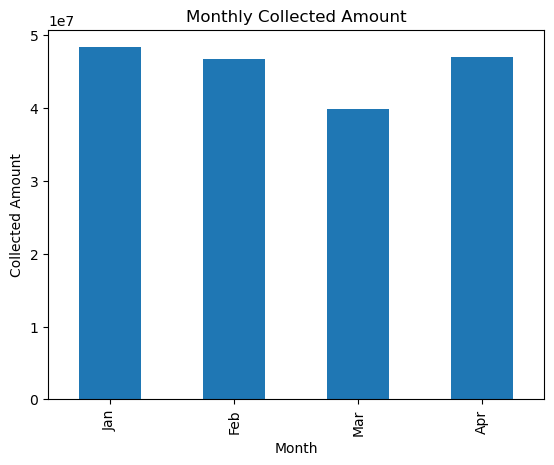

In [10]:
monthly_summary['collected_amount'].plot(kind='bar', title='Monthly Collected Amount')
plt.ylabel('Collected Amount')
plt.xlabel('Month')
plt.show()

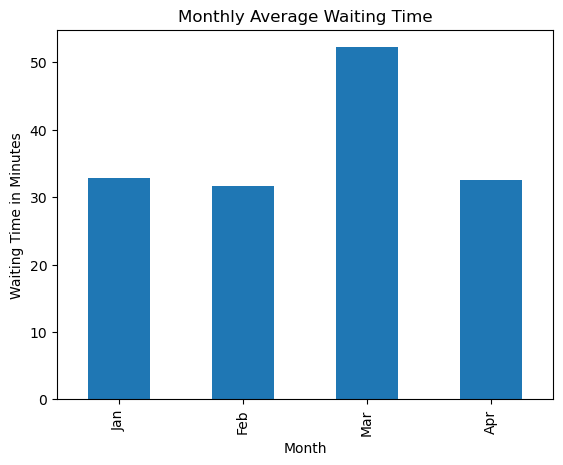

In [11]:
monthly_summary['avg_waiting_time'].plot(kind='bar', title='Monthly Average Waiting Time')
plt.ylabel('Waiting Time in Minutes')
plt.xlabel('Month')
plt.show()

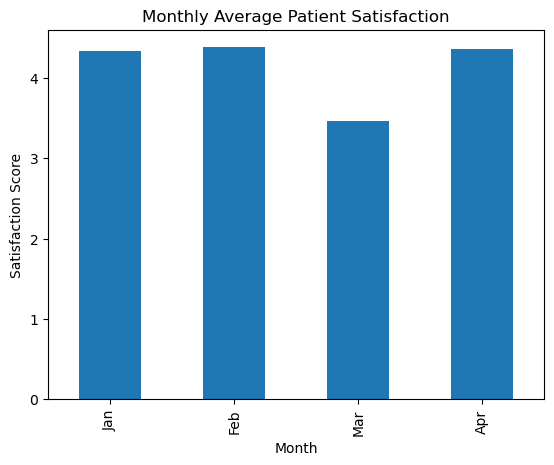

In [12]:
monthly_summary['avg_satisfaction'].plot(kind='bar', title='Monthly Average Patient Satisfaction')
plt.ylabel('Satisfaction Score')
plt.xlabel('Month')
plt.show()

## Checkpoint 3

Questions:

1. Which month needs investigation?
2. Is this only a revenue problem?
3. Which operational KPI changed?
4. What should we drill into next?

Expected answer:

> We should analyze March department-wise.

# 8. Department-Level RCA for March

Now we identify where the problem is coming from.

Filter March data and compare departments.

In [13]:
march_df = df[df['month'] == 'Mar'].copy()

print('March records:', march_df.shape)
march_df.head()

March records: (2227, 23)


,patient_id,visit_date,month,city,department,doctor_name,admission_type,insurance_type,waiting_time_minutes,length_of_stay_days,treatment_cost,discount_percent,billed_amount,collected_amount,payment_status,patient_satisfaction_score,visit_date_raw,date_issue_flag,collection_rate,pending_amount,is_pending_payment,high_wait_flag,low_satisfaction_flag
4,100004,2024-03-02,Mar,Mumbai,Emergency,Dr. Kavya,Routine,Self Pay,96.00,5,27840,15,"23,664.00","2,267.33",Pending,2.70,2024-03-02,False,0.10,"21,396.67",True,True,True
6,100006,2024-03-06,Mar,Chennai,Emergency,Dr. Rohan,Routine,Insurance,46.00,2,15130,20,"12,104.00","12,104.00",Paid,4.00,2024-03-06,False,1.00,0.00,False,False,False
10,100010,2024-03-09,Mar,Pune,Cardiology,Dr. Thomas,Routine,Insurance,64.00,7,31244,15,"26,557.40","26,557.40",Paid,2.60,2024-03-09,False,1.00,0.00,False,True,True
13,100013,2024-03-01,Mar,Bangalore,Emergency,Dr. Nisha,Routine,Insurance,80.00,6,14408,25,"10,806.00","10,806.00",Paid,2.40,2024-03-01,False,1.00,0.00,False,True,True
14,100014,2024-03-26,Mar,Mumbai,Emergency,Dr. Rohan,Emergency,Corporate,71.00,6,25896,20,"20,716.80","20,716.80",Paid,3.70,2024-03-26,False,1.00,0.00,False,True,False


In [14]:
dept_march = march_df.groupby('department').agg(
    patient_count=('patient_id', 'count'),
    collected_amount=('collected_amount', 'sum'),
    pending_amount=('pending_amount', 'sum'),
    collection_rate=('collection_rate', 'mean'),
    avg_waiting_time=('waiting_time_minutes', 'mean'),
    avg_satisfaction=('patient_satisfaction_score', 'mean'),
    high_wait_rate=('high_wait_flag', 'mean'),
    low_satisfaction_rate=('low_satisfaction_flag', 'mean')
).sort_values('pending_amount', ascending=False)

dept_march

,patient_count,collected_amount,pending_amount,collection_rate,avg_waiting_time,avg_satisfaction,high_wait_rate,low_satisfaction_rate
department,,,,,,,,
Cardiology,500,"15,059,718.25","8,191,636.25",0.64,79.40,2.45,0.93,0.76
Orthopedics,275,"7,024,821.70","3,863,252.60",0.65,26.45,4.53,0.00,0.01
Neurology,224,"6,405,294.47","3,693,639.53",0.63,38.54,4.16,0.03,0.04
Emergency,676,"6,495,029.78","3,521,915.82",0.65,70.18,2.68,0.76,0.66
General Medicine,328,"3,185,335.61","1,749,487.74",0.64,24.54,4.54,0.00,0.02
Pediatrics,224,"1,689,371.03","909,451.57",0.65,23.33,4.58,0.00,0.02


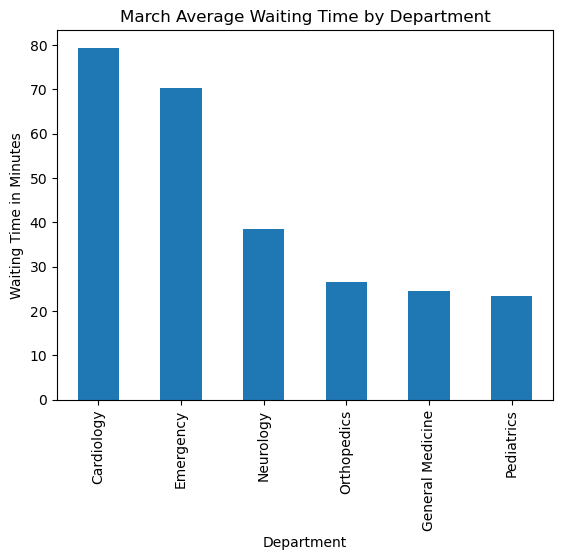

In [15]:
dept_march['avg_waiting_time'].sort_values(ascending=False).plot(
    kind='bar', title='March Average Waiting Time by Department'
)
plt.ylabel('Waiting Time in Minutes')
plt.xlabel('Department')
plt.show()

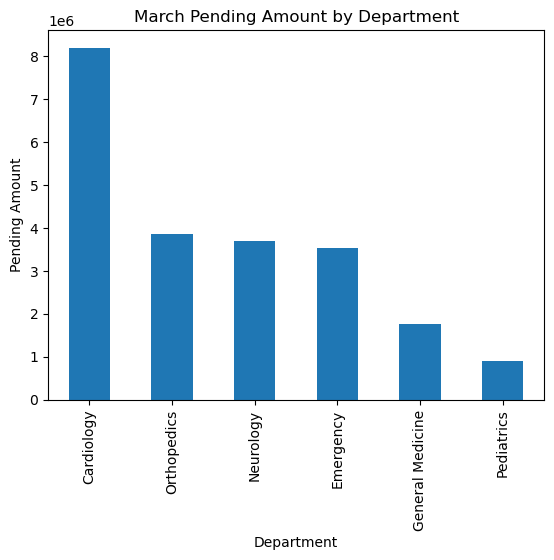

In [16]:
dept_march['pending_amount'].sort_values(ascending=False).plot(
    kind='bar', title='March Pending Amount by Department'
)
plt.ylabel('Pending Amount')
plt.xlabel('Department')
plt.show()

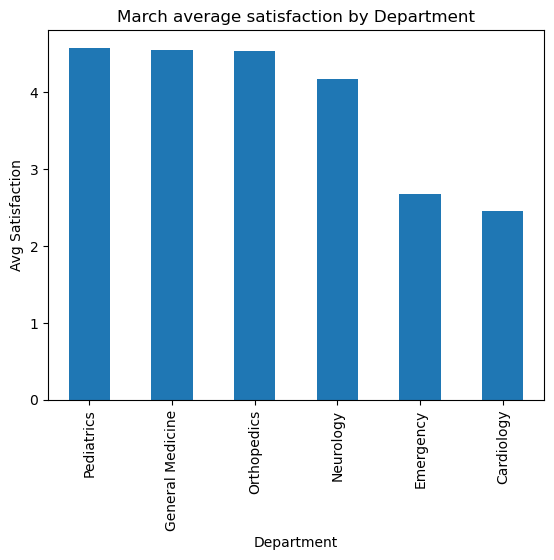

In [17]:
dept_march['avg_satisfaction'].sort_values(ascending=False).plot(
    kind='bar', title='March average satisfaction by Department'
)
plt.ylabel('Avg Satisfaction')
plt.xlabel('Department')
plt.show()

## Interpretation


1. Which department has the highest pending amount?
2. Which department has the highest waiting time?
3. Which department has low satisfaction?
4. Are the same departments appearing repeatedly?

Expected finding:

> Emergency and Cardiology are major contributors to March issues.

# 9. Compare March vs Other Months by Department

A department may naturally have higher waiting time.

So compare March against all other months.

In [18]:
df['period'] = np.where(df['month'] == 'Mar', 'March', 'Other Months')

dept_compare = df.groupby(['department', 'period']).agg(
    patient_count=('patient_id', 'count'),
    avg_waiting_time=('waiting_time_minutes', 'mean'),
    avg_satisfaction=('patient_satisfaction_score', 'mean'),
    pending_amount=('pending_amount', 'sum'),
    collection_rate=('collection_rate', 'mean')
).reset_index()

dept_compare.sort_values(['department', 'period'])

,department,period,patient_count,avg_waiting_time,avg_satisfaction,pending_amount,collection_rate
0,Cardiology,March,500,79.40,2.45,"8,191,636.25",0.64
1,Cardiology,Other Months,1163,45.00,4.08,"13,496,322.69",0.77
2,Emergency,March,676,70.18,2.68,"3,521,915.82",0.65
3,Emergency,Other Months,1417,34.24,4.33,"5,277,708.27",0.78
4,General Medicine,March,328,24.54,4.54,"1,749,487.74",0.64
5,General Medicine,Other Months,1194,24.98,4.51,"3,400,106.65",0.81
6,Neurology,March,224,38.54,4.16,"3,693,639.53",0.63
7,Neurology,Other Months,783,37.80,4.26,"6,700,470.38",0.81
8,Orthopedics,March,275,26.45,4.53,"3,863,252.60",0.65
9,Orthopedics,Other Months,898,28.24,4.43,"7,715,071.93",0.78


## Checkpoint 4


1. Which departments changed most in March?
2. Is the issue spread across all departments?
3. Or is it concentrated?

Expected answer:

> Problem is concentrated mainly in Emergency and Cardiology.

# 10. Admission Type RCA

Emergency cases often create operational pressure because they are unplanned.

Analyze March by admission type.

In [19]:
admission_march = march_df.groupby('admission_type').agg(
    patient_count=('patient_id', 'count'),
    avg_waiting_time=('waiting_time_minutes', 'mean'),
    avg_satisfaction=('patient_satisfaction_score', 'mean'),
    pending_amount=('pending_amount', 'sum'),
    collection_rate=('collection_rate', 'mean')
).sort_values('patient_count', ascending=False)

admission_march

,patient_count,avg_waiting_time,avg_satisfaction,pending_amount,collection_rate
admission_type,,,,,
Routine,978,52.85,3.44,"10,002,986.98",0.64
Emergency,959,51.61,3.51,"9,173,252.97",0.64
Referral,290,52.23,3.44,"2,753,143.56",0.66


## Expected Insight

If Emergency admissions have high patient count and high waiting time, this supports the root cause:

> Increased emergency load created operational pressure in March.

# 11. Doctor Workload Analysis

Sometimes the root cause is not only department-level.
It may be doctor workload imbalance.

Analyze doctor workload in March.

In [20]:
doctor_march = march_df.groupby(['department', 'doctor_name']).agg(
    patient_count=('patient_id', 'count'),
    avg_waiting_time=('waiting_time_minutes', 'mean'),
    avg_satisfaction=('patient_satisfaction_score', 'mean'),
    pending_amount=('pending_amount', 'sum')
).sort_values(['patient_count', 'avg_waiting_time'], ascending=False)

doctor_march.head(15)

patient_count  avg_waiting_time  \
department       doctor_name                                    
Emergency        Dr. Nisha              180             69.88   
                 Dr. Rohan              175             69.49   
                 Dr. Kavya              173             70.58   
                 Dr. Imran              148             70.90   
Cardiology       Dr. Rao                139             79.58   
                 Dr. Thomas             125             78.01   
                 Dr. Anjali             122             80.93   
                 Dr. Mehta              114             79.06   
General Medicine Dr. Reddy              112             26.07   
                 Dr. Das                110             24.49   
                 Dr. Sharma             106             22.98   
Orthopedics      Dr. Varun              100             25.90   
                 Dr. Kiran               93             26.83   
Neurology        Dr. Iyer                84             38.39   
Orthopedics      Dr. Arjun               82             26.68   

                              avg_satisfaction  pending_amount  
department       doctor_name                                    
Emergency        Dr. Nisha                2.60    1,025,276.20  
                 Dr. Rohan                2.65      905,008.21  
                 Dr. Kavya                2.74      778,587.48  
                 Dr. Imran                2.72      813,043.93  
Cardiology       Dr. Rao                  2.44    2,550,761.00  
                 Dr. Thomas               2.44    1,770,187.87  
                 Dr. Anjali               2.35    1,983,976.39  
                 Dr. Mehta                2.57    1,886,710.99  
General Medicine Dr. Reddy                4.49      667,097.88  
                 Dr. Das                  4.58      623,815.19  
                 Dr. Sharma               4.56      458,574.67  
Orthopedics      Dr. Varun                4.57    1,337,632.95  
                 Dr. Kiran                4.45    1,472,327.97  
Neurology        Dr. Iyer                 4.14    1,245,182.64  
Orthopedics      Dr. Arjun                4.58    1,053,291.68

## Checkpoint 5



1. Are a few doctors handling too many patients?
2. Is workload connected with waiting time?
3. Which department needs extra support?

Expected answer:

> High workload in Emergency/Cardiology can increase waiting time and reduce satisfaction.

# 12. Convert Analysis into RCA Story

A good RCA explanation follows this structure:

```text
Problem → Evidence → Root Cause → Recommendation
```

Do not say only:

> Revenue dropped.

Say:

> Revenue collection dropped in March because pending payments increased, especially in Emergency and Cardiology. These departments also had increased waiting time and lower satisfaction, suggesting operational pressure.

# 13. Final Executive Summary — Model Answer

## What happened?

March performance declined across revenue collection, waiting time, pending payments, and satisfaction.

## Evidence

- March waiting time increased compared with other months.
- Patient satisfaction decreased in March.
- Pending payment amount increased.
- Emergency and Cardiology contributed heavily to waiting time and pending amount.
- Emergency admission load increased.

## Root Cause

The likely root cause is increased Emergency and Cardiology demand in March. This created doctor workload pressure, increased waiting time, lowered satisfaction, and increased pending billing cases.

## Recommendations

1. Add temporary doctors/support staff in Emergency and Cardiology during peak demand.
2. Track waiting time daily with alerts above 60 minutes.
3. Monitor pending billing by department every day.
4. Improve patient queue management.
5. Review doctor workload distribution weekly.

#### 1.Which department is the biggest problem area in March?
#### Cardiology and Emergency are the biggest Problem area in march compared to other departmets.

In [22]:
dept_march = march_df.groupby('department').agg(
    patient_count=('patient_id', 'count'),
    collected_amount=('collected_amount', 'sum'),
    pending_amount=('pending_amount', 'sum'),
    collection_rate=('collection_rate', 'mean'),
    avg_waiting_time=('waiting_time_minutes', 'mean'),
    avg_satisfaction=('patient_satisfaction_score', 'mean'),
    high_wait_rate=('high_wait_flag', 'mean'),
    low_satisfaction_rate=('low_satisfaction_flag', 'mean')
).sort_values('pending_amount', ascending=False)

dept_march

,patient_count,collected_amount,pending_amount,collection_rate,avg_waiting_time,avg_satisfaction,high_wait_rate,low_satisfaction_rate
department,,,,,,,,
Cardiology,500,"15,059,718.25","8,191,636.25",0.64,79.40,2.45,0.93,0.76
Orthopedics,275,"7,024,821.70","3,863,252.60",0.65,26.45,4.53,0.00,0.01
Neurology,224,"6,405,294.47","3,693,639.53",0.63,38.54,4.16,0.03,0.04
Emergency,676,"6,495,029.78","3,521,915.82",0.65,70.18,2.68,0.76,0.66
General Medicine,328,"3,185,335.61","1,749,487.74",0.64,24.54,4.54,0.00,0.02
Pediatrics,224,"1,689,371.03","909,451.57",0.65,23.33,4.58,0.00,0.02


#### 2.Which KPI proves it?
#### Department wise Pending Amount,Departmet wise Avg_waiting_time,Department wise avg_satisfaction_score were the KPI proves it.

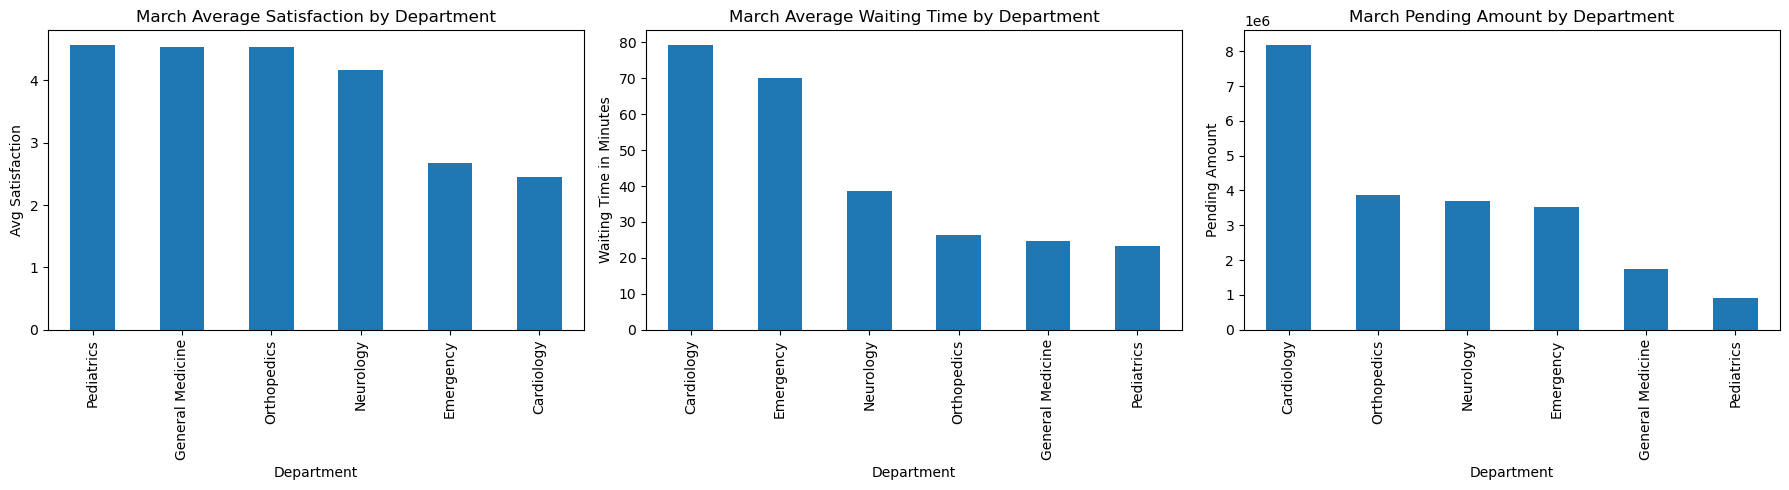

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Avg Satisfaction
dept_march['avg_satisfaction'].sort_values(ascending=False).plot(
    kind='bar',
    ax=axes[0],
    title='March Average Satisfaction by Department'
)
axes[0].set_ylabel('Avg Satisfaction')
axes[0].set_xlabel('Department')

# Avg Waiting Time
dept_march['avg_waiting_time'].sort_values(ascending=False).plot(
    kind='bar',
    ax=axes[1],
    title='March Average Waiting Time by Department'
)
axes[1].set_ylabel('Waiting Time in Minutes')
axes[1].set_xlabel('Department')

# Pending Amount
dept_march['pending_amount'].sort_values(ascending=False).plot(
    kind='bar',
    ax=axes[2],
    title='March Pending Amount by Department'
)
axes[2].set_ylabel('Pending Amount')
axes[2].set_xlabel('Department')

plt.tight_layout()
plt.show()

#### 3. What is the likely root cause?
#### The Root cause is more Patients admitted in these two departments(Cardiology and Emergency) and the doctors workload is increased.

In [26]:
doctor_march = march_df.groupby(['department', 'doctor_name']).agg(
    patient_count=('patient_id', 'count'),
    avg_waiting_time=('waiting_time_minutes', 'mean'),
    avg_satisfaction=('patient_satisfaction_score', 'mean'),
    pending_amount=('pending_amount', 'sum')
).sort_values(['patient_count', 'avg_waiting_time'], ascending=False)

doctor_march.head(15)

patient_count  avg_waiting_time  \
department       doctor_name                                    
Emergency        Dr. Nisha              180             69.88   
                 Dr. Rohan              175             69.49   
                 Dr. Kavya              173             70.58   
                 Dr. Imran              148             70.90   
Cardiology       Dr. Rao                139             79.58   
                 Dr. Thomas             125             78.01   
                 Dr. Anjali             122             80.93   
                 Dr. Mehta              114             79.06   
General Medicine Dr. Reddy              112             26.07   
                 Dr. Das                110             24.49   
                 Dr. Sharma             106             22.98   
Orthopedics      Dr. Varun              100             25.90   
                 Dr. Kiran               93             26.83   
Neurology        Dr. Iyer                84             38.39   
Orthopedics      Dr. Arjun               82             26.68   

                              avg_satisfaction  pending_amount  
department       doctor_name                                    
Emergency        Dr. Nisha                2.60    1,025,276.20  
                 Dr. Rohan                2.65      905,008.21  
                 Dr. Kavya                2.74      778,587.48  
                 Dr. Imran                2.72      813,043.93  
Cardiology       Dr. Rao                  2.44    2,550,761.00  
                 Dr. Thomas               2.44    1,770,187.87  
                 Dr. Anjali               2.35    1,983,976.39  
                 Dr. Mehta                2.57    1,886,710.99  
General Medicine Dr. Reddy                4.49      667,097.88  
                 Dr. Das                  4.58      623,815.19  
                 Dr. Sharma               4.56      458,574.67  
Orthopedics      Dr. Varun                4.57    1,337,632.95  
                 Dr. Kiran                4.45    1,472,327.97  
Neurology        Dr. Iyer                 4.14    1,245,182.64  
Orthopedics      Dr. Arjun                4.58    1,053,291.68

#### 4. What business action should management take?
#### Management should Add few more doctors/staff when patiets count is more and if the pending amount is more then give a little bit discount.

# 15. Optional: Save Cleaned Dataset

This cleaned file can be used later for dashboard or presentation practice.

In [27]:
df.to_csv('hospital_operations_rca_cleaned.csv', index=False)
print('Cleaned RCA dataset saved successfully.')

Cleaned RCA dataset saved successfully.


In [28]:
df.to_csv('E:\\screening\\hospital_operations_rca_cleaned.csv', index=False)
print('Cleaned RCA dataset saved successfully.')

Cleaned RCA dataset saved successfully.


# Closing Script

Say this:

> Today you did not just analyze data. You investigated a business problem.

Then:

> A normal analyst creates charts. A strong analyst explains why the problem happened and what action should be taken.

Final takeaway:

```text
Problem → KPI Validation → Drill Down → Root Cause → Recommendation
```

This is how analysts survive in real jobs.